In [1]:
# Import packages here
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy import integrate
import scipy.stats as ss
from scipy.interpolate import UnivariateSpline
from scipy.stats import poisson
from multiprocessing import Pool
import time
import multiprocessing as mp
import pandas as pd
from scipy.interpolate import interp1d
from astropy.io import fits
from tqdm import tqdm
import functools
%matplotlib notebook

In [2]:
###########################################################################
# Some constants
c = 2.99792458*10**(10)			# cm/s		 
h = 6.6260755*10**(-27)			# erg s
k = 1.380658*10**(-16)				# erg/K
n_avogadro = 6.02214179*10**(23)      	        # Avogadro's number
L_sun = 3.8458*10**(33)			# Units: erg/s
stefan_sigma = 5.67051*10**(-5) 	        # Units: erg.cm^(-2).K^(-4).s^(-1)
pi = math.pi
###########################################################################

In [3]:
###########################################################################
# Function to calculate the specific heat of a molecule
def specific_heat(Temperature_array):
	specific_heat_T = np.array([])
	def planck_sp(T):
		frac = h*freq_fundamental_modes/(k*T)
		frac = frac.astype(np.longdouble)
		expr_a = 1/np.exp(frac/2)
		expr_b = (expr_a)**2
		expr_1 = np.exp(frac)/(frac**2)
		expr_2 = expr_b/(frac**2)
		expr_3 = 2/(frac**2)
		expr_4 = expr_1 + expr_2 - expr_3
		expr_5 = 1/expr_4
		expr = expr_5
		#expr = (frac**2)*np.exp(frac)/((np.exp(frac)-1)**2)
		specific_heat_val = (np.sum(expr))*k
		return specific_heat_val
	specific_heat_T = list(map(planck_sp, Temperature_array))
	specific_heat_T = np.array(specific_heat_T)
	return specific_heat_T
###########################################################################


###########################################################################
def cooling_curve(Temperature_array):
	a = specific_heat(Temperature_array)
	term = 4*pi/(a)
	def planck(nu, sig):
		frac = h*nu/(k*Temperature_array)
		frac = frac.astype(np.longdouble)
		expr_a = 1/(np.exp(frac)-1)
		expr_b = 2*h*(nu**3)/(c**2)
		expr = expr_a*expr_b*sig 
		return expr
	sigma_B_nu_T = list(map(planck, freq_IR_active_modes, xsection))
	sigma_B_nu_T = np.array(sigma_B_nu_T)
	for i in range (0, len(xsection)):
		a = sigma_B_nu_T[i]
		if i == 0:
			b = a
			cooling_curve_T = b
		else:
			b = cooling_curve_T+a
			cooling_curve_T = b
			
	cooling_curve_T = term*cooling_curve_T
	return cooling_curve_T
###########################################################################

###########################################################################
# Function to calculate rbar
def rbar(Temp_star, G_0):
	freq_photon_energy = energy_absorption_x_section*(1.60218*10**(-12))/h 
	Temp_star = float(Temp_star)
	frac = h*freq_photon_energy/(k*Temp_star)
	frac = frac.astype(np.longdouble)
	expr_a = 1/(np.exp(frac)-1)
	expr_b = 2*h*(freq_photon_energy**3)/(c**2)
	B_nu_array = expr_a*expr_b
	mean_photon_intensity = B_nu_array/(h*freq_photon_energy)
	
	energy_array_FUV = np.linspace(6, 13.6, 1000)
	frequency_array_FUV = energy_array_FUV*(1.60218*10**(-12))/h
	frac = h*frequency_array_FUV/(k*Temp_star)
	frac = frac.astype(np.longdouble)
	expr_a = 1/(np.exp(frac)-1)
	expr_b = 2*h*(frequency_array_FUV**3)/(c**2)
	B_nu_FUV = expr_a*expr_b
	Total_flux = stefan_sigma*(Temp_star)**(4)
	Flux_FUV = (pi)*(integrate.simps(B_nu_FUV, frequency_array_FUV))
	frac_FUV = Flux_FUV/Total_flux
	Field_dilution_factor = 1.6*10**(-3)*(G_0)/(stefan_sigma*((Temp_star)**(4))*frac_FUV)
	
	expr = pi*Field_dilution_factor*absorption_x_section*mean_photon_intensity
	rbar_calc = (integrate.simps(expr, freq_photon_energy))
	return rbar_calc

###########################################################################
# for each temp value, lets create a temperature_grid 
def create_temp_grid(T_max, T_min):
    diff = T_max - T_min
    if diff < 50:
        temp_array = np.arange(T_min, T_max, 0.01)
    else:
        temp_array = np.arange(T_min, T_max, 1)    
        
    return temp_array

def expr_tau_min_calc(array):
        return 1/array
    
def calculate_tau_min(expr, t_array):
        tau_min_val = integrate.simps(expr,t_array)
        return tau_min_val

In [4]:

###########################################################################
# Function to calculate the maximum temperature that a molecule reaches upon absorption of a UV photon
def Temp_max(energy, fine_tune = False):
    # Initialize temperature list with the background temperature of 2.7 K
    temp_list = [2.7]
    energy_calc_eV = 0.0
    step = 10  # Start with a larger step for faster convergence
    energy_list = [0.0]

    # Loop to increase temperature until reaching the energy target
    while energy_calc_eV < energy:
        specific_heat_T_new = specific_heat(np.array(temp_list))
        energy_calc = integrate.simps(specific_heat_T_new, temp_list)
        energy_calc_eV = energy_calc / (1.6021772 * 10**(-12))

        if energy_calc_eV < energy:
            temp_list.append(temp_list[-1] + step)
            energy_list.append(energy_calc_eV)

            
    # Fine-tune the temperature with smaller steps if needed
    if fine_tune:
        step = 0.1
        while abs(energy_calc_eV - energy) > 0.01:  # Adjust tolerance as necessary
            specific_heat_T_new = specific_heat(np.array(temp_list))
            energy_calc = integrate.simps(specific_heat_T_new, temp_list)
            energy_calc_eV = energy_calc / (1.6021772 * 10**(-12))

            # Adjust temperature based on whether we are above or below the energy
            if energy_calc_eV > energy:
                temp_list.append(temp_list[-1] - step)
            else:
                temp_list.append(temp_list[-1] + step)

    # Final temperature and array
    T_max = temp_list[-1]
    
    return T_max, temp_list, energy_list


def calculate_G_T(row):
    T = row['new_T_grid']
    T_max_val = row['T_max']
    
    temp_grid_partial = functools.partial(create_temp_grid, T_max_val)
    temp_grids_for_tau_min = np.array(list(map(temp_grid_partial, T)))
    
    # lets calculate the time it takes for a molecule to cool from T_max_val
    cc_t = list(map(cc_func, temp_grids_for_tau_min)) #cooling curves
    expr_t = list(map(expr_tau_min_calc, cc_t)) # 1/cooling curve
    tau_min_t = list(map(calculate_tau_min, expr_t, temp_grids_for_tau_min))
    tau_min_t = np.array(tau_min_t)

    
    rate_param = rbar_calc*tau_min_t
    exp_fac = np.exp(-rate_param)
    G_T_num = rbar_calc*exp_fac
    G_T_denom = cc_func(T)
    G_1_T = G_T_num/G_T_denom
    int_number = integrate.simps(G_1_T, T)

    return G_1_T, int_number



def calculate_G_T_new(row):
    T = row['new_T_grid']
    T_max_val = row['T_max']
    dT=0.1
  
    dTdt = cc_func(T)
    inv_rate = 1/dTdt
    tau_min_t = np.cumsum(inv_rate[::-1])[::-1]*dT

    
    rate_param = rbar_calc*tau_min_t
    exp_fac = np.exp(-rate_param)
    G_T_num = rbar_calc*exp_fac
    G_T_denom = cc_func(T)
    G_1_T = G_T_num/G_T_denom
    int_number = integrate.simps(G_1_T, T)

    return G_1_T, int_number


def calculate_Gn_T(row, iteration, dT=0.1):
    new_T_grid = np.asarray(row['new_T_grid'], dtype = float)
    iteration = int(iteration)
    col_name_temp = f't_max_{iteration}'
    iteration = int(iteration-1)
    col_name_G = f'G_{iteration}_T'
    t_max_n = np.asarray(row[col_name_temp], dtype = float)
    Gprev_T = np.asarray(row[col_name_G], dtype = float)
    
    # ---- 1. Build the extended grid
    T_top = float(np.max(t_max_n))
    T_grid_full = np.arange(1, T_top+dT/2, dT)
    N = T_grid_full.size
    
    # ---- 2. dT/dt on the extended curve
    dTdt_full = np.asarray(cc_func(T_grid_full), dtype = float)
    
    # ---- 3. Cumulative cool-down time t(T) from top down to T
    inv_rate = 1.0/dTdt_full
    t_of_T = np.cumsum(inv_rate[::-1])[::-1]*dT
    t_of_T -= t_of_T[-1]
    
    # ---- 4. Separable pieces of the kernel G(T; T_peak) = f(T)*g(T_peak)
    f_T = (rbar_calc/dTdt_full)*np.exp(-rbar_calc*t_of_T)
    g_Tpeak = np.exp(rbar_calc*t_of_T)
    
    # ----5. Map new_T_grid and t_max_2 onto indices of T_grid_full
    T0 = T_grid_full[0]
    idx_t2 = np.rint((t_max_n - T0)/dT).astype(int)
    idx_t2 = np.clip(idx_t2, 0, N-1)
    
    # ----6. Weights per absorption point
    w_prime = Gprev_T*g_Tpeak[idx_t2]*dT
    
    
    # ----7. Scatter into bins at idx_t2
    scatter = np.zeros(N)
    np.add.at(scatter, idx_t2, w_prime)
    S_T = np.cumsum(scatter[::-1])[::-1]
    
    # ----8. Assemble
    G_n_T = f_T*S_T
    
    return T_grid_full, G_n_T



# Function to calculate the intensities of IR active modes
def intensities_nu_erg_per_s(G_T, Temp_array):
    intensity_nu = np.array([])
    for i in range(0, len(xsection)):
        G_T_B_nu_T = np.array([])
        frac = h*freq_IR_active_modes[i]/(k*Temp_array)
        frac = frac.astype(np.longdouble)
        expr_a = 1/(np.exp(frac)-1)
        expr_b = 2*h*(freq_IR_active_modes[i]**3)/(c**2)
        expr = expr_a*expr_b
        G_T_B_nu_val = G_T*expr
        G_T_B_nu_T = np.append(G_T_B_nu_T, G_T_B_nu_val)
        integral = integrate.simps(G_T_B_nu_T, Temp_array)
        intensity_nu_val = xsection[i]*integral
        intensity_nu = np.append(intensity_nu, intensity_nu_val)
    return intensity_nu


def run_Gn_calculations(df, iteration):
    grids = []
    probs = []
    for _, row in df.iterrows():
        Tg, Gn = calculate_Gn_T(row, iteration)
        grids.append(Tg)
        probs.append(Gn)
    df = df.copy()
    df['new_T_grid'] = grids
    G_col_name = f'G_{iteration}_T'
    df[G_col_name] = probs
    return df

In [5]:
###########################################################################
if __name__ == "__main__":
    start_time = time.time()
    Temp_star = float(15000) #Temperature of central star of NGC 7023; Units: K
    G_0 = 10000
    
    # Some infor for the molecule
    energy_absorption_x_section = np.loadtxt("abs_cross-section_coronene_neutral.csv",
                                             delimiter = ',', skiprows = 1, usecols = (0))
    ind = np.where(energy_absorption_x_section < 13.6)
    ind = ind[0]
    absorption_x_section = np.loadtxt("abs_cross-section_coronene_neutral.csv",
                                      delimiter = ',', skiprows = 1, usecols = (1))
    energy_absorption_x_section = energy_absorption_x_section[ind]
    absorption_x_section = absorption_x_section[ind] #Units: Mb
    absorption_x_section = absorption_x_section*10**(-18) #Units: cm^(2)
    
    ###########################################################################
    num_c_atoms = 18
    correction_factor = 1#0.66
    print ('Correction factor is', correction_factor)
    ###########################################################################
    # Import Data here
    data_C60 = np.loadtxt("coronene_neutral_IR_active.csv", 
                          delimiter = ',', skiprows = 1, usecols = (0,1)) 

    wno_IR_active_modes = data_C60[:,0] # Units: cm^(-1)
    ind = np.where((wno_IR_active_modes>2750)&(wno_IR_active_modes<3250))
    ind = ind[0]
    freq_IR_active_modes = c*wno_IR_active_modes # units: Hz 
    
    wno_fundamental_modes = np.loadtxt("coronene_neutral.csv",
                                       delimiter = ',', skiprows = 1,  usecols = (0)) # Units: cm^(-1)

    freq_fundamental_modes = c*wno_fundamental_modes # Units: Hz 

    int_intensity = data_C60[:,1] 	# Units: km/mol
    xsection = int_intensity*c*(10**5)/n_avogadro 	# Units: cm^(2).Hz
    xsection[ind] = xsection[ind]*correction_factor
    ###########################################################################
    
    # First we will calculate the maximum temperature a molecule will reach if it absorbs 13.6 eV photon
    photon_energy = 13.6
    number_of_photons = 3
    T = Temp_max(photon_energy*number_of_photons, fine_tune = False)
    
    # Lets define a temperature grid
    T_min = 1 #K
    T_max = T[0] - 0.1
    T_grid = np.arange(T_min, T_max, 0.1)
    
    # Calculate specific heat
    cv_grid = specific_heat(T_grid)
    
    # calculate cooling curve
    cc_grid = cooling_curve(T_grid)
    
    # for use in the calculations
    # convert cc_grid, Temptoenergy conversions into a function, 
    temp_to_energy_func = interp1d(T[1], T[2], fill_value = 'extrapolate') # T[2] is Energey, T[1] is max_temp
    mx_temp_func_2 = interp1d(T[2], T[1], fill_value = 'extrapolate')
    cc_func = interp1d(T_grid, cc_grid, fill_value = 'extrapolate')
    
     # calculate rbar
    rbar_calc = rbar(Temp_star, G_0)
    
    # calculate G_T
    G_T = pd.DataFrame({'E_p': T[2],
                      'T_max': T[1]})
    G_T_subset = G_T[(G_T['E_p'] != 0)]
    G_T_subset = G_T_subset[(G_T_subset['E_p'] <= 13.6)]
    
    G_T_subset['T_grid'] = [T_grid]*len(G_T_subset)
    G_T_subset['new_T_grid'] = G_T_subset.apply(lambda row: [t for t in row['T_grid'] if t< row['T_max']],
                                                axis = 1)
    G_T_subset = G_T_subset[['E_p', 'T_max', 'new_T_grid']]
    
    results = G_T_subset.apply(calculate_G_T_new, axis = 1)
    G_T_subset['G_1_T'], G_T_subset['int_results'] = zip(*results)
    
    # Second photon
    G_T_subset = G_T_subset.reset_index(drop=True)
    G_T_subset['e_grid_2'] = G_T_subset['new_T_grid']
    G_T_subset['t_max_2'] = G_T_subset['new_T_grid']
    for i in range (0, len(G_T_subset)):
        t_grid = G_T_subset['new_T_grid'][i]
        G_T_subset['e_grid_2'][i] = temp_to_energy_func(t_grid)
        G_T_subset['e_grid_2'][i] = G_T_subset['e_grid_2'][i] + G_T_subset['E_p'][i]
        e_grid = G_T_subset['e_grid_2'][i]
        G_T_subset['t_max_2'][i] = mx_temp_func_2(e_grid)
    
    G_T_subset = run_Gn_calculations(G_T_subset, iteration = 2) # second photon
    
    # Third photon
    G_T_subset['e_grid_3'] = G_T_subset['new_T_grid']
    G_T_subset['t_max_3'] = G_T_subset['new_T_grid']
    for i in range (0, len(G_T_subset)):
        t_grid = G_T_subset['new_T_grid'][i]
        G_T_subset['e_grid_3'][i] = temp_to_energy_func(t_grid)
        G_T_subset['e_grid_3'][i] = G_T_subset['e_grid_3'][i] + G_T_subset['E_p'][i]
        e_grid = G_T_subset['e_grid_3'][i]
        G_T_subset['t_max_3'][i] = mx_temp_func_2(e_grid)
    
    G_T_master = run_Gn_calculations(G_T_subset, iteration = 3) # third photon
    
    
    # Read the Kurucz model
    file_name = 'kp00_15000.fits'
    hdul = fits.open(file_name)
    data = hdul[1].data
    data_native = {col: data[col].byteswap().newbyteorder() for col in data.names}
    kurucz_df = pd.DataFrame(data_native)
    kurucz_df = kurucz_df[['WAVELENGTH', 'g40']] #erg/s/cm2/angstrom
    kurucz_df['flux_erg'] = 1e-8*kurucz_df['g40']*kurucz_df['WAVELENGTH']**2/(h*c)
    kurucz_df['flux_eV'] = (1.60218*10**(-12))*kurucz_df['flux_erg']
    kurucz_df['wave_cm'] = kurucz_df['WAVELENGTH']*1e-8 # in cm
    kurucz_df['energy'] = h*c/kurucz_df['wave_cm']
    kurucz_df['energy'] = kurucz_df['energy']/ (1.60218*10**(-12))
    kurucz_model = interp1d(kurucz_df['energy'], kurucz_df['flux_eV'])
    
    G_T_master = G_T_master[G_T_master['E_p'] > kurucz_df['energy'].min()]
    kurucz_flux = kurucz_model(G_T_master['E_p'])
    G_T_master['kurucz_flux'] = kurucz_flux

    G_T_master['G_n_T_nE'] = G_T_master.apply(
        lambda row: (np.array(row['G_3_T'])*row['kurucz_flux']).tolist(), axis = 1)

    max_len = G_T_master['G_n_T_nE'].apply(len).max()

    G_T_master['G_n_T_nE'] = G_T_master['G_n_T_nE'].apply(lambda x: x +[0.0]*(max_len - len(x)))
    
    array_data = np.array(G_T_master['G_n_T_nE'].tolist())
    array_data_T = array_data.T

    e_array = G_T_master['E_p'].tolist() 
    flux_array = G_T_master['kurucz_flux'].tolist()
    G_n_T_final_num = []
    for i in range (0, max_len):
        G_n_T_array = array_data_T[i]
        G_n_T_array = np.nan_to_num(G_n_T_array, nan = 0.0)
    
        int_number = integrate.simps(G_n_T_array, e_array)
        G_n_T_final_num.append(int_number)
    
    G_n_T_final_denom =  integrate.simps(flux_array, e_array)
    G_n_T_final = np.array([G_n_T_final_num])/G_n_T_final_denom
    T_array = G_T_master['new_T_grid'].iloc[-1]
    
   
    intensity_array = intensities_nu_erg_per_s(G_n_T_final, T_array)
        
    print ("My program took", time.time() - start_time, "to run")
   
      
    


Correction factor is 1


/Users/ameeksidhu/opt/anaconda3/lib/python3.8/site-packages/numpy/core/_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
<ipython-input-5-f438211e8764>:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  G_T_subset['e_grid_2'][i] = temp_to_energy_func(t_grid)
<ipython-input-5-f438211e8764>:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  G_T_

My program took 128.9755299091339 to run


In [6]:
path = "/Users/ameeksidhu/Documents/Theory_project_Bethany/code/output/"
data_Xander = np.loadtxt(path + "C24H12_0_10000_G.txt")
data_Xander = data_Xander.T
temp_Xander = data_Xander[0,:]
G_T_Xander = data_Xander[1,:]

<IPython.core.display.Javascript object>


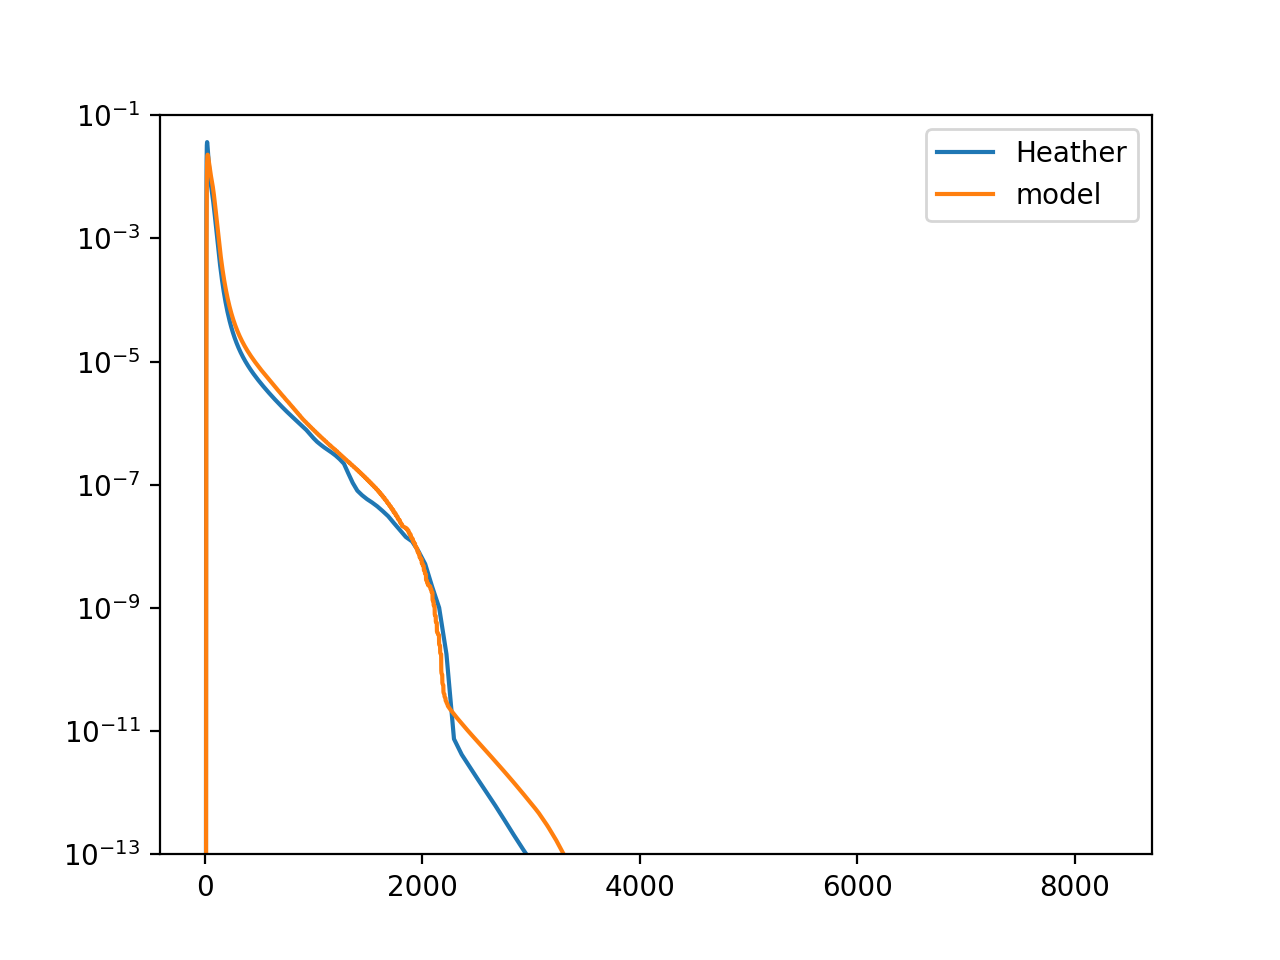

In [7]:
plt.plot(temp_Xander, G_T_Xander, label = 'Heather')
plt.plot(T_array, G_n_T_final[0], label = 'model')
plt.yscale('log')
plt.ylim(10**-13, 10**(-1))
plt.legend()